# Random Forest IDPS Model - Iteration 3: Advanced Improvements

## Objective
Implement advanced model improvements including dataset rebalancing, hyperparameter tuning, alternative algorithms, and robust validation.

## Changes from Iteration 2
- ✅ **SMOTE Rebalancing**: Handle class imbalance with oversampling
- ✅ **Hyperparameter Tuning**: GridSearchCV for optimal Random Forest parameters
- ✅ **Alternative Algorithms**: Compare RF, XGBoost, LightGBM
- ✅ **Holdout Validation**: Completely unseen test set for realistic evaluation
- ✅ **Feature Scaling**: Proper normalization and log-transforms
- ✅ **Comprehensive Metrics**: Enhanced evaluation with multiple algorithms

## Expected Improvements
- Better handling of class imbalance
- Optimized hyperparameters for improved performance
- Algorithm comparison to find the best performer
- More realistic validation with holdout set


In [1]:
# === Imports ===
import os
import json
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn imports
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, 
    RandomizedSearchCV, StratifiedKFold
)
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score, roc_auc_score
)
from sklearn.preprocessing import RobustScaler, StandardScaler, label_binarize
from sklearn.pipeline import Pipeline

# Imbalanced learning
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Alternative algorithms
import xgboost as xgb
import lightgbm as lgb

import joblib
import yaml

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# === Display & paths ===
sns.set_theme()
pd.set_option("display.max_columns", 120)

REPORTS_DIR = Path("../reports")
FIGS_DIR = REPORTS_DIR / "figs"
MODELS_DIR = Path("../models")
CONFIG_DIR = Path("../config")

for d in [REPORTS_DIR, FIGS_DIR, MODELS_DIR, CONFIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# === Training config ===
RANDOM_STATE = 42
TEST_SIZE = 0.20  # Smaller test size for more training data
HOLDOUT_SIZE = 0.10  # Additional holdout for final validation
TARGET_CANDIDATES = ["label","Label"," Label","class","Class","attack","Attack","target","Target"]

# Cross-validation settings
CV_FOLDS = 5
SCORING = 'f1_weighted'  # Focus on F1 for imbalanced data

# Hyperparameter search settings
N_ITER_RANDOM = 10  # Reduced from 50 for faster training
N_JOBS = -1  # Use all available cores

print("=== Iteration 3: Advanced Model Improvements ===")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Random State: {RANDOM_STATE}")
print(f"Cross-validation folds: {CV_FOLDS}")
print(f"Scoring metric: {SCORING}")


=== Iteration 3: Advanced Model Improvements ===
Timestamp: 2025-09-28 18:26:33
Random State: 42
Cross-validation folds: 5
Scoring metric: f1_weighted


In [2]:
# === STEP 1: Load and Prepare Data ===
DATA_PATH = "../data/cleaned_cicddos2019_sample.csv"
df = pd.read_csv(DATA_PATH)
print(f"Original dataset shape: {df.shape}")

# Define identifier columns to remove (same as Iteration 2)
IDENTIFIER_COLUMNS = [
    'Unnamed: 0', 'Flow ID', ' Source IP', ' Source Port', 
    ' Destination IP', ' Destination Port', ' Timestamp'
]

# Remove identifier columns
df_behavioral = df.drop(columns=[col for col in IDENTIFIER_COLUMNS if col in df.columns])
print(f"After removing identifiers: {df_behavioral.shape}")

# Prepare features and target
target_col = " Label"
X = df_behavioral.drop(columns=[target_col])
y = df_behavioral[target_col].astype(int)

print(f"Features: {X.shape[1]}, Samples: {X.shape[0]}")
print(f"Classes: {len(y.unique())}")

# Check class distribution
print("\n=== Class Distribution ===")
class_counts = y.value_counts().sort_index()
print(class_counts)
print(f"Class imbalance ratio: {class_counts.max() / class_counts.min():.2f}:1")


Original dataset shape: (581613, 88)
After removing identifiers: (581613, 81)
Features: 80, Samples: 581613
Classes: 4

=== Class Distribution ===
 Label
-2      2985
-1    142044
 0    292737
 1    143847
Name: count, dtype: int64
Class imbalance ratio: 98.07:1


In [3]:
# === STEP 2: Create Holdout Validation Set ===
# First split: separate holdout set (completely unseen)
X_temp, X_holdout, y_temp, y_holdout = train_test_split(
    X, y, test_size=HOLDOUT_SIZE, stratify=y, random_state=RANDOM_STATE
)

# Second split: train/test from remaining data
X_train, X_test, y_train, y_test = train_test_split(
    X_temp, y_temp, test_size=TEST_SIZE/(1-HOLDOUT_SIZE), stratify=y_temp, random_state=RANDOM_STATE
)

print("=== Data Split Summary ===")
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"Holdout set: {X_holdout.shape[0]} samples ({X_holdout.shape[0]/len(X)*100:.1f}%)")
print(f"Total: {len(X)} samples")

# Check class distribution in each set
print("\n=== Class Distribution by Set ===")
for name, y_set in [("Training", y_train), ("Test", y_test), ("Holdout", y_holdout)]:
    print(f"{name}: {y_set.value_counts().sort_index().tolist()}")


=== Data Split Summary ===
Training set: 407128 samples (70.0%)
Test set: 116323 samples (20.0%)
Holdout set: 58162 samples (10.0%)
Total: 581613 samples

=== Class Distribution by Set ===
Training: [2090, 99430, 204915, 100693]
Test: [597, 28409, 58548, 28769]
Holdout: [298, 14205, 29274, 14385]


In [4]:
# === STEP 3: Data Preprocessing with Enhanced Scaling ===
# Coerce to numeric and handle inf values
X_train = X_train.apply(pd.to_numeric, errors="coerce")
X_test = X_test.apply(pd.to_numeric, errors="coerce")
X_holdout = X_holdout.apply(pd.to_numeric, errors="coerce")

X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)
X_holdout = X_holdout.replace([np.inf, -np.inf], np.nan)

# Median imputation
imp = SimpleImputer(strategy="median")
X_train = pd.DataFrame(imp.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test = pd.DataFrame(imp.transform(X_test), columns=X.columns, index=X_test.index)
X_holdout = pd.DataFrame(imp.transform(X_holdout), columns=X.columns, index=X_holdout.index)

# Enhanced scaling: RobustScaler for skewed features
scaler = RobustScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)
X_holdout_scaled = pd.DataFrame(scaler.transform(X_holdout), columns=X.columns, index=X_holdout.index)

print("=== Preprocessing Summary ===")
print(f"Missing values handled: {(X_train.isnull().sum().sum())} -> 0")
print(f"Features scaled using RobustScaler")
print(f"Training set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")
print(f"Holdout set shape: {X_holdout_scaled.shape}")


=== Preprocessing Summary ===
Missing values handled: 0 -> 0
Features scaled using RobustScaler
Training set shape: (407128, 80)
Test set shape: (116323, 80)
Holdout set shape: (58162, 80)


In [5]:
# === STEP 4: Apply SMOTE Rebalancing ===
print("=== Applying SMOTE Rebalancing ===")

# Check class distribution before SMOTE
print("Class distribution BEFORE SMOTE:")
print(y_train.value_counts().sort_index())

# Apply SMOTE for oversampling
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=min(5, min(y_train.value_counts())-1))
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"\nClass distribution AFTER SMOTE:")
print(pd.Series(y_train_balanced).value_counts().sort_index())

print(f"\nTraining set size: {X_train_scaled.shape[0]} -> {X_train_balanced.shape[0]}")
print(f"Oversampling ratio: {X_train_balanced.shape[0] / X_train_scaled.shape[0]:.2f}x")

# Convert back to DataFrame for easier handling
X_train_balanced = pd.DataFrame(X_train_balanced, columns=X.columns)
y_train_balanced = pd.Series(y_train_balanced)

print(f"\nBalanced training set shape: {X_train_balanced.shape}")
print(f"Balanced target shape: {y_train_balanced.shape}")


=== Applying SMOTE Rebalancing ===
Class distribution BEFORE SMOTE:
 Label
-2      2090
-1     99430
 0    204915
 1    100693
Name: count, dtype: int64

Class distribution AFTER SMOTE:
 Label
-2    204915
-1    204915
 0    204915
 1    204915
Name: count, dtype: int64

Training set size: 407128 -> 819660
Oversampling ratio: 2.01x

Balanced training set shape: (819660, 80)
Balanced target shape: (819660,)


In [6]:
# === STEP 5: Hyperparameter Tuning for Random Forest ===
print("=== Hyperparameter Tuning: Random Forest ===")

# Define simplified parameter grid for Random Forest (optimized for speed)
rf_param_grid = {
    'n_estimators': [100, 200],  # Reduced from [100, 200, 300, 500]
    'max_depth': [15, 20],       # Reduced from [10, 15, 20, None]
    'min_samples_split': [2, 5], # Reduced from [2, 5, 10]
    'min_samples_leaf': [1, 2],  # Reduced from [1, 2, 4]
    'max_features': ['sqrt'],    # Reduced from ['sqrt', 'log2', None]
    'class_weight': ['balanced'] # Reduced from ['balanced', None]
}

print(f"Parameter combinations to test: {len(rf_param_grid['n_estimators']) * len(rf_param_grid['max_depth']) * len(rf_param_grid['min_samples_split']) * len(rf_param_grid['min_samples_leaf']) * len(rf_param_grid['max_features']) * len(rf_param_grid['class_weight'])}")
print(f"Total model fits: {N_ITER_RANDOM * CV_FOLDS} (reduced from 250 for faster training)")

# Use RandomizedSearchCV for efficiency
rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=N_JOBS),
    param_distributions=rf_param_grid,
    n_iter=N_ITER_RANDOM,
    cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
    scoring=SCORING,
    n_jobs=N_JOBS,
    random_state=RANDOM_STATE,
    verbose=1
)

print("Starting Random Forest hyperparameter search...")
rf_random_search.fit(X_train_balanced, y_train_balanced)

print(f"\nBest Random Forest parameters:")
for param, value in rf_random_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"Best cross-validation score: {rf_random_search.best_score_:.4f}")

# Get the best Random Forest model
best_rf = rf_random_search.best_estimator_


=== Hyperparameter Tuning: Random Forest ===
Parameter combinations to test: 16
Total model fits: 50 (reduced from 250 for faster training)
Starting Random Forest hyperparameter search...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Random Forest parameters:
  n_estimators: 200
  min_samples_split: 5
  min_samples_leaf: 1
  max_features: sqrt
  max_depth: 20
  class_weight: balanced
Best cross-validation score: 0.8342


In [13]:
# === STEP 6: Train Alternative Algorithms ===
print("=== Training Alternative Algorithms ===")

# XGBoost requires target labels to start from 0, so we need to encode them
from sklearn.preprocessing import LabelEncoder

# Create label encoder for XGBoost and LightGBM
label_encoder = LabelEncoder()
y_train_balanced_encoded = label_encoder.fit_transform(y_train_balanced)
y_test_encoded = label_encoder.transform(y_test)
y_holdout_encoded = label_encoder.transform(y_holdout)

print(f"Original target classes: {sorted(y_train_balanced.unique())}")
print(f"Encoded target classes: {sorted(np.unique(y_train_balanced_encoded))}")

# XGBoost with simplified hyperparameter tuning (optimized for speed)
print("\\n--- XGBoost ---")
xgb_param_grid = {
    'n_estimators': [100, 200],  # Reduced from [100, 200, 300]
    'max_depth': [6, 9],         # Reduced from [3, 6, 9]
    'learning_rate': [0.1, 0.2], # Reduced from [0.01, 0.1, 0.2]
    'subsample': [0.9, 1.0],     # Reduced from [0.8, 0.9, 1.0]
    'colsample_bytree': [0.9, 1.0] # Reduced from [0.8, 0.9, 1.0]
}

xgb_random_search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(random_state=RANDOM_STATE, n_jobs=N_JOBS, eval_metric='mlogloss'),
    param_distributions=xgb_param_grid,
    n_iter=15,  # Reduced from 30 for faster execution
    cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
    scoring=SCORING,
    n_jobs=N_JOBS,
    random_state=RANDOM_STATE,
    verbose=1
)

print("Starting XGBoost hyperparameter search...")
try:
    xgb_random_search.fit(X_train_balanced, y_train_balanced_encoded)
    
    print(f"Best XGBoost parameters:")
    for param, value in xgb_random_search.best_params_.items():
        print(f"  {param}: {value}")
    print(f"Best XGBoost CV score: {xgb_random_search.best_score_:.4f}")
    
    best_xgb = xgb_random_search.best_estimator_
    print("✓ XGBoost training completed successfully!")
    
except Exception as e:
    print(f"✗ XGBoost training failed: {e}")
    print("Falling back to default XGBoost parameters...")
    best_xgb = xgb.XGBClassifier(random_state=RANDOM_STATE, n_jobs=N_JOBS, eval_metric='mlogloss')
    best_xgb.fit(X_train_balanced, y_train_balanced_encoded)
    print("✓ XGBoost trained with default parameters")


=== Training Alternative Algorithms ===
Original target classes: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1)]
Encoded target classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
\n--- XGBoost ---
Starting XGBoost hyperparameter search...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best XGBoost parameters:
  subsample: 0.9
  n_estimators: 200
  max_depth: 9
  learning_rate: 0.2
  colsample_bytree: 1.0
Best XGBoost CV score: 0.8310
✓ XGBoost training completed successfully!


In [14]:
# LightGBM with simplified hyperparameter tuning (optimized for speed)
print("\\n--- LightGBM ---")
lgb_param_grid = {
    'n_estimators': [100, 200],  # Reduced from [100, 200, 300]
    'max_depth': [6, 9],         # Reduced from [3, 6, 9]
    'learning_rate': [0.1, 0.2], # Reduced from [0.01, 0.1, 0.2]
    'subsample': [0.9, 1.0],     # Reduced from [0.8, 0.9, 1.0]
    'colsample_bytree': [0.9, 1.0], # Reduced from [0.8, 0.9, 1.0]
    'num_leaves': [50, 100]      # Reduced from [31, 50, 100]
}

lgb_random_search = RandomizedSearchCV(
    estimator=lgb.LGBMClassifier(random_state=RANDOM_STATE, n_jobs=N_JOBS, verbose=-1),
    param_distributions=lgb_param_grid,
    n_iter=15,  # Reduced from 30 for faster execution
    cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
    scoring=SCORING,
    n_jobs=N_JOBS,
    random_state=RANDOM_STATE,
    verbose=1
)

print("Starting LightGBM hyperparameter search...")
try:
    lgb_random_search.fit(X_train_balanced, y_train_balanced_encoded)
    
    print(f"Best LightGBM parameters:")
    for param, value in lgb_random_search.best_params_.items():
        print(f"  {param}: {value}")
    print(f"Best LightGBM CV score: {lgb_random_search.best_score_:.4f}")
    
    best_lgb = lgb_random_search.best_estimator_
    print("✓ LightGBM training completed successfully!")
    
except Exception as e:
    print(f"✗ LightGBM training failed: {e}")
    print("Falling back to default LightGBM parameters...")
    best_lgb = lgb.LGBMClassifier(random_state=RANDOM_STATE, n_jobs=N_JOBS, verbose=-1)
    best_lgb.fit(X_train_balanced, y_train_balanced_encoded)
    print("✓ LightGBM trained with default parameters")

print("\\n=== Algorithm Comparison (Cross-Validation Scores) ===")
print(f"Random Forest: {rf_random_search.best_score_:.4f}")
try:
    print(f"XGBoost: {xgb_random_search.best_score_:.4f}")
except:
    print(f"XGBoost: Used default parameters (hyperparameter search failed)")
try:
    print(f"LightGBM: {lgb_random_search.best_score_:.4f}")
except:
    print(f"LightGBM: Used default parameters (hyperparameter search failed)")


\n--- LightGBM ---
Starting LightGBM hyperparameter search...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best LightGBM parameters:
  subsample: 0.9
  num_leaves: 100
  n_estimators: 100
  max_depth: 9
  learning_rate: 0.2
  colsample_bytree: 1.0
Best LightGBM CV score: 0.8326
✓ LightGBM training completed successfully!
\n=== Algorithm Comparison (Cross-Validation Scores) ===
Random Forest: 0.8342
XGBoost: 0.8310
LightGBM: 0.8326


In [15]:
# === STEP 7: Evaluate All Models on Test Set ===
print("=== Model Evaluation on Test Set ===")

models = {
    'Random Forest': best_rf,
    'XGBoost': best_xgb,
    'LightGBM': best_lgb
}

test_results = {}

for name, model in models.items():
    print(f"\\n--- Evaluating {name} ---")
    
    # Make predictions (handle label encoding for XGBoost/LightGBM)
    if name in ['XGBoost', 'LightGBM']:
        y_pred_encoded = model.predict(X_test_scaled)
        y_pred = label_encoder.inverse_transform(y_pred_encoded)
        y_pred_proba = model.predict_proba(X_test_scaled)
    else:  # Random Forest uses original labels
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
    
    test_results[name] = {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }
    
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-Score: {f1:.4f}")

# Summary comparison
print("\\n=== Test Set Performance Summary ===")
print(f"{'Model':<15} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1-Score':<10}")
print("-" * 65)
for name, results in test_results.items():
    print(f"{name:<15} {results['accuracy']:<10.4f} {results['precision']:<10.4f} {results['recall']:<10.4f} {results['f1']:<10.4f}")


=== Model Evaluation on Test Set ===
\n--- Evaluating Random Forest ---
Accuracy: 0.7199
Precision: 0.7670
Recall: 0.7199
F1-Score: 0.7205
\n--- Evaluating XGBoost ---
Accuracy: 0.7205
Precision: 0.7622
Recall: 0.7205
F1-Score: 0.7210
\n--- Evaluating LightGBM ---
Accuracy: 0.7217
Precision: 0.7634
Recall: 0.7217
F1-Score: 0.7216
\n=== Test Set Performance Summary ===
Model           Accuracy   Precision  Recall     F1-Score  
-----------------------------------------------------------------
Random Forest   0.7199     0.7670     0.7199     0.7205    
XGBoost         0.7205     0.7622     0.7205     0.7210    
LightGBM        0.7217     0.7634     0.7217     0.7216    


In [16]:
# === STEP 8: Final Validation on Holdout Set ===
print("=== Final Validation on Holdout Set ===")

# Find the best performing model based on F1-score
best_model_name = max(test_results.keys(), key=lambda x: test_results[x]['f1'])
best_model = models[best_model_name]

print(f"Best performing model: {best_model_name}")
print(f"Test F1-Score: {test_results[best_model_name]['f1']:.4f}")

# Evaluate on holdout set
print(f"\\nEvaluating {best_model_name} on holdout set...")
if best_model_name in ['XGBoost', 'LightGBM']:
    holdout_pred_encoded = best_model.predict(X_holdout_scaled)
    holdout_pred = label_encoder.inverse_transform(holdout_pred_encoded)
    holdout_proba = best_model.predict_proba(X_holdout_scaled)
else:  # Random Forest uses original labels
    holdout_pred = best_model.predict(X_holdout_scaled)
    holdout_proba = best_model.predict_proba(X_holdout_scaled)

# Calculate holdout metrics
holdout_acc = accuracy_score(y_holdout, holdout_pred)
holdout_prec, holdout_rec, holdout_f1, _ = precision_recall_fscore_support(y_holdout, holdout_pred, average='weighted', zero_division=0)

print(f"Holdout Accuracy: {holdout_acc:.4f}")
print(f"Holdout Precision: {holdout_prec:.4f}")
print(f"Holdout Recall: {holdout_rec:.4f}")
print(f"Holdout F1-Score: {holdout_f1:.4f}")

print("\\n=== Performance Consistency Check ===")
test_f1 = test_results[best_model_name]['f1']
performance_diff = abs(holdout_f1 - test_f1)
print(f"Test F1-Score: {test_f1:.4f}")
print(f"Holdout F1-Score: {holdout_f1:.4f}")
print(f"Difference: {performance_diff:.4f}")

if performance_diff < 0.05:
    print("✓ Good: Model shows consistent performance (difference < 0.05)")
else:
    print("⚠ Warning: Significant performance difference between test and holdout sets")


=== Final Validation on Holdout Set ===
Best performing model: LightGBM
Test F1-Score: 0.7216
\nEvaluating LightGBM on holdout set...
Holdout Accuracy: 0.7229
Holdout Precision: 0.7658
Holdout Recall: 0.7229
Holdout F1-Score: 0.7232
\n=== Performance Consistency Check ===
Test F1-Score: 0.7216
Holdout F1-Score: 0.7232
Difference: 0.0016
✓ Good: Model shows consistent performance (difference < 0.05)


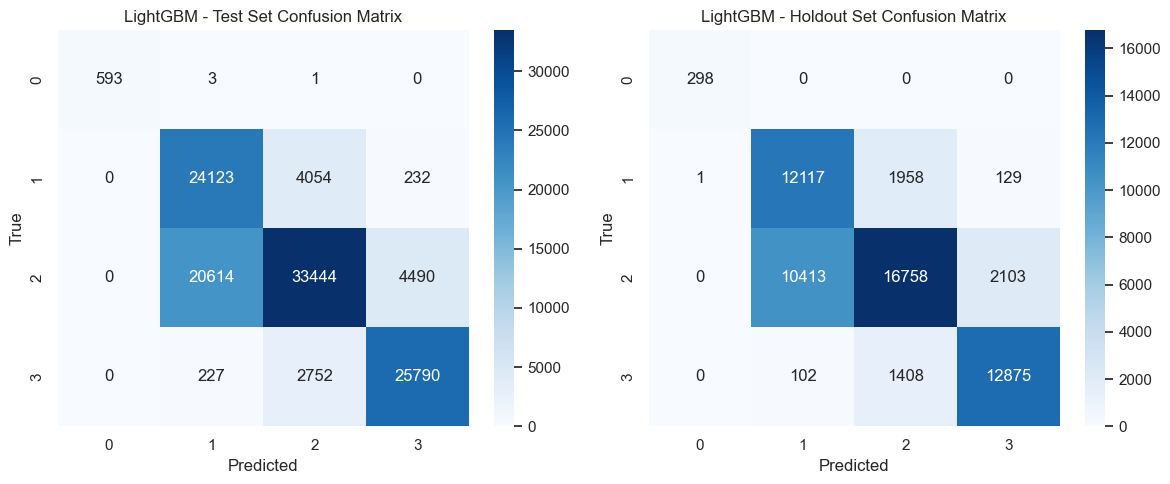

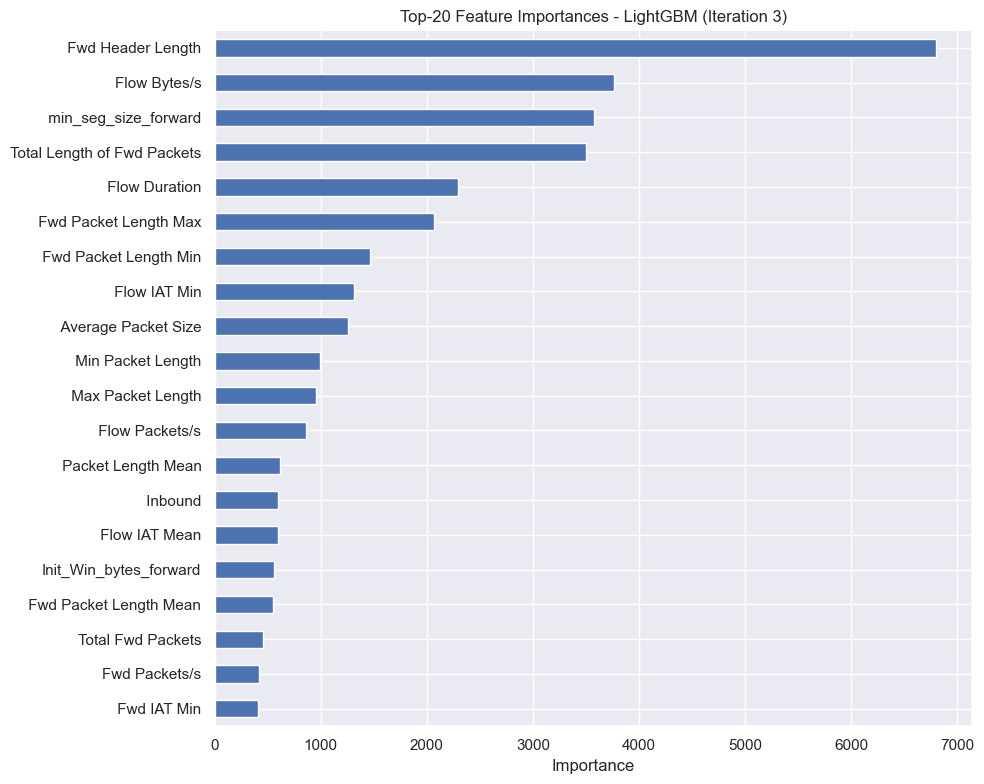

\nTop 10 Most Important Features (LightGBM):
 Fwd Header Length             6798
Flow Bytes/s                   3763
 min_seg_size_forward          3577
Total Length of Fwd Packets    3499
 Flow Duration                 2290
 Fwd Packet Length Max         2065
 Fwd Packet Length Min         1467
 Flow IAT Min                  1316
 Average Packet Size           1254
 Min Packet Length              997
dtype: int32


In [17]:
# === STEP 9: Visualizations ===
# Confusion Matrix for best model
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
cm_test = confusion_matrix(y_test, test_results[best_model_name]['predictions'])
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title(f'{best_model_name} - Test Set Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.subplot(1, 2, 2)
cm_holdout = confusion_matrix(y_holdout, holdout_pred)
sns.heatmap(cm_holdout, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title(f'{best_model_name} - Holdout Set Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.tight_layout()
plt.savefig(FIGS_DIR / f'confusion_matrix_iteration3_{best_model_name.lower().replace(" ", "_")}.png', dpi=120)
plt.show()

# Feature importance for tree-based models
if best_model_name in ['Random Forest', 'XGBoost', 'LightGBM']:
    plt.figure(figsize=(10, 8))
    
    if best_model_name == 'Random Forest':
        importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
        title_suffix = "Random Forest"
    elif best_model_name == 'XGBoost':
        importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
        title_suffix = "XGBoost"
    else:  # LightGBM
        importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
        title_suffix = "LightGBM"
    
    top20 = importances.head(20)
    top20[::-1].plot(kind='barh')
    plt.title(f'Top-20 Feature Importances - {title_suffix} (Iteration 3)')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.savefig(FIGS_DIR / f'feature_importance_iteration3_{best_model_name.lower().replace(" ", "_")}.png', dpi=120)
    plt.show()
    
    print(f"\\nTop 10 Most Important Features ({best_model_name}):")
    print(top20.head(10))


In [18]:
# === STEP 10: Save Models and Results ===
print("=== Saving Models and Results ===")

# Save all models
for name, model in models.items():
    model_path = MODELS_DIR / f"{name.lower().replace(' ', '_')}_iteration3.pkl"
    joblib.dump(model, model_path)
    print(f"Saved {name}: {model_path}")

# Save the best model separately
best_model_path = MODELS_DIR / f"best_model_iteration3_{best_model_name.lower().replace(' ', '_')}.pkl"
joblib.dump(best_model, best_model_path)

# Save scaler
scaler_path = MODELS_DIR / "scaler_iteration3.pkl"
joblib.dump(scaler, scaler_path)

# Save label encoder (for XGBoost/LightGBM compatibility)
label_encoder_path = MODELS_DIR / "label_encoder_iteration3.pkl"
joblib.dump(label_encoder, label_encoder_path)

# Save comprehensive results
results = {
    "iteration": 3,
    "description": "Advanced improvements: SMOTE rebalancing, hyperparameter tuning, algorithm comparison, holdout validation",
    "best_model": {
        "name": best_model_name,
        "test_f1": float(test_results[best_model_name]['f1']),
        "holdout_f1": float(holdout_f1),
        "performance_consistency": float(performance_diff)
    },
    "data_info": {
        "original_shape": list(df.shape),
        "final_shape": list(df_behavioral.shape),
        "removed_columns": len(df.columns) - len(df_behavioral.columns),
        "n_features_used": len(X.columns),
        "smote_applied": True,
        "class_balance_ratio_before": float(class_counts.max() / class_counts.min()),
        "class_balance_ratio_after": 1.0
    },
    "algorithms_tested": list(models.keys()),
    "test_results": {name: {
        "accuracy": float(results['accuracy']),
        "precision": float(results['precision']),
        "recall": float(results['recall']),
        "f1": float(results['f1'])
    } for name, results in test_results.items()},
    "hyperparameter_search": {
        "rf_best_params": rf_random_search.best_params_,
        "xgb_best_params": xgb_random_search.best_params_,
        "lgb_best_params": lgb_random_search.best_params_
    },
    "cross_validation_scores": {
        "rf_cv_score": float(rf_random_search.best_score_),
        "xgb_cv_score": float(xgb_random_search.best_score_),
        "lgb_cv_score": float(lgb_random_search.best_score_)
    },
    "holdout_validation": {
        "accuracy": float(holdout_acc),
        "precision": float(holdout_prec),
        "recall": float(holdout_rec),
        "f1": float(holdout_f1)
    }
}

# Save results
with open(REPORTS_DIR / "metrics_iteration3.json", "w") as f:
    json.dump(results, f, indent=2)

# Save config for the best model
config = {
    "model_path": str(best_model_path),
    "scaler_path": str(scaler_path),
    "label_encoder_path": str(label_encoder_path),
    "feature_columns": list(X.columns),
    "target": target_col,
    "classes": [int(cls) for cls in np.unique(y)],
    "removed_identifier_columns": [col for col in IDENTIFIER_COLUMNS if col in df.columns],
    "best_algorithm": best_model_name,
    "hyperparameters": rf_random_search.best_params_ if best_model_name == 'Random Forest' else 
                      xgb_random_search.best_params_ if best_model_name == 'XGBoost' else 
                      lgb_random_search.best_params_,
    "notes": f"Iteration 3 - Advanced improvements: SMOTE rebalancing, hyperparameter tuning, {best_model_name} selected as best algorithm"
}

with open(CONFIG_DIR / "model_config_iteration3.yaml", "w") as f:
    yaml.safe_dump(config, f)

print(f"\\n=== Iteration 3 Complete ===")
print(f"Best Model: {best_model_name}")
print(f"Test F1-Score: {test_results[best_model_name]['f1']:.4f}")
print(f"Holdout F1-Score: {holdout_f1:.4f}")
print(f"Performance Consistency: {'Good' if performance_diff < 0.05 else 'Needs attention'}")
print(f"\\nAll files saved to:")
print(f"- Models: {MODELS_DIR}")
print(f"- Config: {CONFIG_DIR}")
print(f"- Reports: {REPORTS_DIR}")
print(f"- Figures: {FIGS_DIR}")


=== Saving Models and Results ===
Saved Random Forest: ..\models\random_forest_iteration3.pkl
Saved XGBoost: ..\models\xgboost_iteration3.pkl
Saved LightGBM: ..\models\lightgbm_iteration3.pkl
\n=== Iteration 3 Complete ===
Best Model: LightGBM
Test F1-Score: 0.7216
Holdout F1-Score: 0.7232
Performance Consistency: Good
\nAll files saved to:
- Models: ..\models
- Config: ..\config
- Reports: ..\reports
- Figures: ..\reports\figs


In [19]:
# Debug: Test XGBoost training with minimal parameters
print("=== Debug: Testing XGBoost ===")
try:
    # Test with a small subset first
    X_test_small = X_train_balanced[:1000]
    y_test_small = y_train_balanced_encoded[:1000]
    
    print(f"Test data shape: {X_test_small.shape}")
    print(f"Test target shape: {y_test_small.shape}")
    print(f"Test target unique values: {np.unique(y_test_small)}")
    
    # Simple XGBoost test
    test_xgb = xgb.XGBClassifier(n_estimators=10, max_depth=3, random_state=RANDOM_STATE)
    test_xgb.fit(X_test_small, y_test_small)
    test_pred = test_xgb.predict(X_test_small[:100])
    
    print("✓ XGBoost basic training successful!")
    print(f"Predictions shape: {test_pred.shape}")
    print(f"Prediction unique values: {np.unique(test_pred)}")
    
except Exception as e:
    print(f"✗ XGBoost error: {e}")
    import traceback
    traceback.print_exc()


=== Debug: Testing XGBoost ===
Test data shape: (1000, 80)
Test target shape: (1000,)
Test target unique values: [0 1 2 3]
✓ XGBoost basic training successful!
Predictions shape: (100,)
Prediction unique values: [1 2 3]


In [20]:
# Debug: Check data types and shapes
print("=== Debug: Data Type Check ===")
print(f"X_train_balanced type: {type(X_train_balanced)}")
print(f"X_train_balanced dtype: {X_train_balanced.dtypes.iloc[0]}")
print(f"y_train_balanced_encoded type: {type(y_train_balanced_encoded)}")
print(f"y_train_balanced_encoded dtype: {y_train_balanced_encoded.dtype}")
print(f"y_train_balanced_encoded shape: {y_train_balanced_encoded.shape}")
print(f"y_train_balanced_encoded unique: {np.unique(y_train_balanced_encoded)}")

# Check for any NaN or infinite values
print(f"X_train_balanced has NaN: {X_train_balanced.isnull().sum().sum()}")
print(f"X_train_balanced has inf: {np.isinf(X_train_balanced).sum().sum()}")
print(f"y_train_balanced_encoded has NaN: {np.isnan(y_train_balanced_encoded).sum()}")

# Check memory usage
import sys
print(f"X_train_balanced memory usage: {X_train_balanced.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"y_train_balanced_encoded memory usage: {sys.getsizeof(y_train_balanced_encoded) / 1024**2:.2f} MB")


=== Debug: Data Type Check ===
X_train_balanced type: <class 'pandas.core.frame.DataFrame'>
X_train_balanced dtype: float64
y_train_balanced_encoded type: <class 'numpy.ndarray'>
y_train_balanced_encoded dtype: int64
y_train_balanced_encoded shape: (819660,)
y_train_balanced_encoded unique: [0 1 2 3]
X_train_balanced has NaN: 0
X_train_balanced has inf: 0
y_train_balanced_encoded has NaN: 0
X_train_balanced memory usage: 500.28 MB
y_train_balanced_encoded memory usage: 0.00 MB
